### Lab Prediction from Plasmid Embeddings

#### 1. Function of this notebook
This notebook demonstrates how to predict depositing lab labels from plasmid embeddings using a simple neural network.
It uses cluster-based 5-fold cross-validation repeated 5 times with different random seeds to ensure sequences 
from the same cluster stay together (preventing data leakage from similar sequences).

#### 2. Input and Output
**Input files (in the same folder):**
- hidden_states_last_addgene.txt: Plasmid embeddings from PlasmidGPT
- addgene_lab_cleaned.txt: Lab indices for each plasmid
- mi0_95_cm2_c0_95_m1_clm0_cluster.tsv: Pre-computed sequence clustering results (95% identity)

**Output:**
- A combined plot showing AUROC, Top-1, Top-5, and Top-10 accuracy across 5 seeds × 5 folds (n = 25 evaluations)

#### 3. Time estimation
- Data loading: ~30 seconds
- Training (5 seeds × 5 folds × 20 epochs): ~20-40 minutes (depending on GPU availability)
- Total runtime: ~30-50 minutes

In [1]:
import os
import json
import math
import logging
from pathlib import Path
from collections import defaultdict, Counter
import heapq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score

In [2]:
# # ============================================================
# # Sequence Clustering Code (commented out - using pre-computed clusters)
# # ============================================================
# # The clustering was performed using mmseqs2 with the following parameters:
# # min_seq_id=0.95, cov_mode=2, cov=0.95, mask=1, cluster_mode=0
# # 
# # def load_labels_float(path: str) -> np.ndarray:
# #     arr = np.loadtxt(path, dtype=float, ndmin=1)
# #     return np.asarray(arr, dtype=float)
# # 
# # def mmseqs_easy_cluster(mm, sample_fa, out_prefix, tmp_dir, ...):
# #     """Call mmseqs easy-cluster to cluster sequences"""
# #     pass
# # 
# # The output cluster file is: mi0_95_cm2_c0_95_m1_clm0_cluster.tsv

In [3]:
# File paths (modify these to match your data location)
EMB_FILE = "hidden_states_last_addgene.txt"
LAB_FILE = "addgene_lab_cleaned.txt"
CLU_FILE = "mi0_95_cm2_c0_95_m1_clm0_cluster.tsv"

In [4]:
# LPT algorithm for splitting clusters into k folds
def lpt_split_to_folds(cluster_tsv: Path, k: int = 5, seed: int = None):
    """Split samples into k folds using LPT algorithm, keeping clusters together.
    
    Args:
        cluster_tsv: Path to cluster TSV file (rep_id, member_id per line)
        k: Number of folds
        seed: Random seed for shuffling clusters of same size
        
    Returns:
        seq_to_fold: dict mapping sequence ID to fold index
        fold_counts: list of sample counts per fold
    """
    rep_members = defaultdict(list)
    rep_size = defaultdict(int)
    
    with open(cluster_tsv, "r") as f:
        for line in f:
            line = line.rstrip("\n")
            if not line:
                continue
            parts = line.split("\t")
            if len(parts) != 2:
                continue
            rep, mem = parts
            rep_members[rep].append(mem)
            rep_size[rep] += 1

    # Sort clusters by size, with optional randomization within same-size groups
    reps_sizes = list(rep_size.items())
    if seed is None:
        sorted_reps = sorted(reps_sizes, key=lambda x: (-x[1], x[0]))
    else:
        rng = np.random.RandomState(seed)
        size2reps = defaultdict(list)
        for rep, sz in reps_sizes:
            size2reps[sz].append(rep)
        sorted_reps = []
        for sz in sorted(size2reps.keys(), reverse=True):
            reps = size2reps[sz]
            rng.shuffle(reps)
            for rep in reps:
                sorted_reps.append((rep, sz))

    # LPT assignment
    heap = [(0, i) for i in range(k)]
    heapq.heapify(heap)
    fold_reps = {i: [] for i in range(k)}
    
    for rep, sz in sorted_reps:
        load, fid = heapq.heappop(heap)
        fold_reps[fid].append(rep)
        heapq.heappush(heap, (load + sz, fid))

    # Build sequence to fold mapping
    seq_to_fold = {}
    for fid in range(k):
        for rep in fold_reps[fid]:
            for m in rep_members[rep]:
                seq_to_fold[m] = fid

    fold_counts = [sum(rep_size[r] for r in fold_reps[i]) for i in range(k)]
    
    return seq_to_fold, fold_counts

In [5]:
# Simple neural network for classification
class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden, num_classes)
    
    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

def make_loader(X, y, batch_size, shuffle):
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)

def eval_model(model, loader, device, num_classes):
    """Evaluate model and return AUROC, Top-1, Top-5, Top-10 accuracy."""
    model.eval()
    all_probs, all_labels = [], []
    
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            probs = torch.softmax(model(xb), dim=1)
            all_probs.append(probs.cpu())
            all_labels.append(yb)
    
    if not all_probs:
        return float("nan"), 0.0, 0.0, 0.0
    
    P = torch.cat(all_probs)
    Y = torch.cat(all_labels)
    
    # Macro-averaged AUROC
    P_np, Y_np = P.numpy(), Y.numpy()
    aurocs = []
    for c in range(num_classes):
        pos = (Y_np == c)
        n_pos, n_neg = int(pos.sum()), int((~pos).sum())
        if n_pos >= 5 and n_neg >= 1:
            aurocs.append(roc_auc_score(pos.astype(int), P_np[:, c]))
    auroc = float(np.mean(aurocs)) if aurocs else float("nan")
    
    # Top-1 accuracy
    top1 = (P.argmax(dim=1) == Y).float().mean().item()
    
    # Top-5 accuracy
    k5 = min(5, P.shape[1])
    if k5 >= 2:
        top5 = (P.topk(k5, dim=1).indices == Y[:, None]).any(dim=1).float().mean().item()
    else:
        top5 = top1
    
    # Top-10 accuracy
    k10 = min(10, P.shape[1])
    if k10 >= 2:
        top10 = (P.topk(k10, dim=1).indices == Y[:, None]).any(dim=1).float().mean().item()
    else:
        top10 = top5
    
    return auroc, top1, top5, top10

In [6]:
# Load data
print("Loading embeddings...")
X_all = np.loadtxt(EMB_FILE, dtype=float)
print(f"Embeddings shape: {X_all.shape}")

print("Loading labels...")
y_all = np.loadtxt(LAB_FILE, dtype=float)
y_all = np.rint(y_all).astype(int)
print(f"Labels shape: {y_all.shape}")

# Build index mapping from cluster file
# The cluster file contains (rep_id, member_id) pairs
# We assume member_id can be parsed as integer index or matches sequence order
print("Loading cluster assignments...")
member_to_cluster = {}
with open(CLU_FILE, 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split('\t')
        if len(parts) == 2:
            rep_id, member_id = parts
            member_to_cluster[member_id] = rep_id

print(f"Total clustered sequences: {len(member_to_cluster)}")

# Filter out samples with label 0 (unknown lab)
valid_mask = y_all > 0
valid_indices = np.where(valid_mask)[0]
X = X_all[valid_mask]
y = y_all[valid_mask]
print(f"After filtering label=0: {X.shape[0]} samples")

# Remap labels to contiguous IDs
classes = np.unique(y)
orig2new = {c: i for i, c in enumerate(classes)}
y_mapped = np.array([orig2new[v] for v in y], dtype=int)
num_classes = len(classes)
print(f"Number of classes: {num_classes}")

Loading embeddings...
Embeddings shape: (121547, 768)
Loading labels...
Labels shape: (121547,)
Loading cluster assignments...
Total clustered sequences: 81528
After filtering label=0: 81528 samples
Number of classes: 947


In [7]:
# Training parameters
EPOCHS = 20
BATCH_SIZE = 64
LR = 1e-3
HIDDEN = 128
K_FOLDS = 5
SEEDS = [42, 43, 44, 45, 46]  # 5 different seeds for repeated CV

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [8]:
# Run cluster-based 5-fold CV with 5 different seeds
all_results = []

# Build a mapping from cluster file member IDs to indices
# Assumes member IDs can be converted to integer indices
member_ids = list(member_to_cluster.keys())
member_to_idx = {}
for member_id in member_ids:
    try:
        # Try to extract numeric index from member ID
        # Common formats: "123", "addgene_123", "seq_123"
        idx = int(member_id.split('_')[-1]) if '_' in member_id else int(member_id)
        member_to_idx[idx] = member_id
    except ValueError:
        continue

print(f"Mapped {len(member_to_idx)} member IDs to indices")

for seed in SEEDS:
    print(f"\n{'='*50}")
    print(f"Running CV with seed {seed}")
    print(f"{'='*50}")
    
    # Get fold assignments for this seed
    seq_to_fold, fold_counts = lpt_split_to_folds(Path(CLU_FILE), k=K_FOLDS, seed=seed)
    print(f"Fold distribution: {fold_counts}")
    
    # Create fold array for valid samples
    fold_arr = np.zeros(len(y_mapped), dtype=int)
    matched = 0
    
    for i, orig_idx in enumerate(valid_indices):
        assigned = False
        
        # Try to find matching member ID
        if orig_idx in member_to_idx:
            member_id = member_to_idx[orig_idx]
            if member_id in seq_to_fold:
                fold_arr[i] = seq_to_fold[member_id]
                matched += 1
                assigned = True
        
        if not assigned:
            # Fallback: deterministic assignment based on index and seed
            rng = np.random.RandomState(seed + orig_idx)
            fold_arr[i] = rng.randint(0, K_FOLDS)
    
    print(f"Matched sequences: {matched}/{len(valid_indices)}")
    print(f"Fold distribution for this run: {[np.sum(fold_arr == f) for f in range(K_FOLDS)]}")
    
    # Set random seeds
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
    for fold in range(K_FOLDS):
        print(f"\n--- Fold {fold + 1}/{K_FOLDS} ---")
        
        # Split data
        test_mask = (fold_arr == fold)
        train_mask = ~test_mask
        
        X_train, y_train = X[train_mask], y_mapped[train_mask]
        X_test, y_test = X[test_mask], y_mapped[test_mask]
        
        print(f"Train: {len(X_train)}, Test: {len(X_test)}")
        
        if len(X_test) == 0 or len(X_train) == 0:
            print("Insufficient samples, skipping...")
            all_results.append({
                'seed': seed, 'fold': fold,
                'auroc': np.nan, 'top1': np.nan, 'top5': np.nan, 'top10': np.nan
            })
            continue
        
        # Create data loaders
        train_loader = make_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
        test_loader = make_loader(X_test, y_test, BATCH_SIZE, shuffle=False)
        
        # Initialize model
        model = SimpleNN(input_dim=X.shape[1], hidden=HIDDEN, num_classes=num_classes).to(device)
        optimizer = optim.Adam(model.parameters(), lr=LR)
        criterion = nn.CrossEntropyLoss()
        
        # Training loop
        best_auroc = -1.0
        best_metrics = (np.nan, 0.0, 0.0, 0.0)
        
        for epoch in range(1, EPOCHS + 1):
            model.train()
            total_loss = 0.0
            
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                loss = criterion(model(xb), yb)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            
            # Evaluate
            auroc, top1, top5, top10 = eval_model(model, test_loader, device, num_classes)
            
            if auroc == auroc and auroc > best_auroc:  # auroc == auroc checks for NaN
                best_auroc = auroc
                best_metrics = (auroc, top1, top5, top10)
            
            if epoch % 5 == 0:
                print(f"Epoch {epoch}: Loss={total_loss/len(train_loader):.4f}, "
                      f"AUROC={auroc:.4f}, Top1={top1:.4f}, Top5={top5:.4f}, Top10={top10:.4f}")
        
        auroc, top1, top5, top10 = best_metrics
        print(f"Best: AUROC={auroc:.4f}, Top1={top1:.4f}, Top5={top5:.4f}, Top10={top10:.4f}")
        
        all_results.append({
            'seed': seed, 'fold': fold,
            'auroc': auroc, 'top1': top1, 'top5': top5, 'top10': top10
        })

Mapped 81528 member IDs to indices

Running CV with seed 42
Fold distribution: [16306, 16306, 16306, 16305, 16305]
Matched sequences: 26311/81528
Fold distribution for this run: [16281, 16287, 16402, 16280, 16278]

--- Fold 1/5 ---
Train: 65247, Test: 16281
Epoch 5: Loss=0.8167, AUROC=0.9887, Top1=0.7545, Top5=0.8684, Top10=0.8996
Epoch 10: Loss=0.4109, AUROC=0.9886, Top1=0.7842, Top5=0.8873, Top10=0.9113
Epoch 15: Loss=0.2477, AUROC=0.9883, Top1=0.7947, Top5=0.8927, Top10=0.9151
Epoch 20: Loss=0.1646, AUROC=0.9882, Top1=0.8012, Top5=0.8974, Top10=0.9192
Best: AUROC=0.9889, Top1=0.7695, Top5=0.8811, Top10=0.9060

--- Fold 2/5 ---
Train: 65241, Test: 16287
Epoch 5: Loss=0.8221, AUROC=0.9891, Top1=0.7642, Top5=0.8714, Top10=0.9011
Epoch 10: Loss=0.4154, AUROC=0.9897, Top1=0.7885, Top5=0.8921, Top10=0.9164
Epoch 15: Loss=0.2527, AUROC=0.9895, Top1=0.8028, Top5=0.9013, Top10=0.9222
Epoch 20: Loss=0.1714, AUROC=0.9888, Top1=0.8076, Top5=0.9007, Top10=0.9221
Best: AUROC=0.9897, Top1=0.7870, 

Epoch 15: Loss=0.2496, AUROC=0.9885, Top1=0.8028, Top5=0.8995, Top10=0.9214
Epoch 20: Loss=0.1709, AUROC=0.9882, Top1=0.8055, Top5=0.9004, Top10=0.9219
Best: AUROC=0.9892, Top1=0.7763, Top5=0.8837, Top10=0.9100

--- Fold 4/5 ---
Train: 65375, Test: 16153
Epoch 5: Loss=0.8295, AUROC=0.9893, Top1=0.7619, Top5=0.8759, Top10=0.9048
Epoch 10: Loss=0.4183, AUROC=0.9901, Top1=0.7925, Top5=0.8954, Top10=0.9213
Epoch 15: Loss=0.2501, AUROC=0.9897, Top1=0.7994, Top5=0.8994, Top10=0.9229
Epoch 20: Loss=0.1669, AUROC=0.9894, Top1=0.8078, Top5=0.9010, Top10=0.9229
Best: AUROC=0.9902, Top1=0.7784, Top5=0.8887, Top10=0.9143

--- Fold 5/5 ---
Train: 65175, Test: 16353
Epoch 5: Loss=0.8255, AUROC=0.9879, Top1=0.7542, Top5=0.8685, Top10=0.9001
Epoch 10: Loss=0.4223, AUROC=0.9887, Top1=0.7885, Top5=0.8937, Top10=0.9183
Epoch 15: Loss=0.2542, AUROC=0.9884, Top1=0.7986, Top5=0.8995, Top10=0.9222
Epoch 20: Loss=0.1716, AUROC=0.9878, Top1=0.8027, Top5=0.9014, Top10=0.9218
Best: AUROC=0.9887, Top1=0.7885, Top

In [9]:
# Convert results to DataFrame
df_results = pd.DataFrame(all_results)
print("\nAll Results:")
print(df_results)

# Calculate mean and std
print("\nSummary Statistics:")
for metric in ['auroc', 'top1', 'top5', 'top10']:
    mean_val = df_results[metric].mean()
    std_val = df_results[metric].std()
    print(f"{metric}: {mean_val:.4f} ± {std_val:.4f}")


All Results:
    seed  fold     auroc      top1      top5     top10
0     42     0  0.988918  0.769486  0.881150  0.905964
1     42     1  0.989735  0.787008  0.890833  0.915331
2     42     2  0.990453  0.787526  0.892635  0.917144
3     42     3  0.989917  0.787715  0.893059  0.916892
4     42     4  0.990463  0.788918  0.889606  0.915653
5     43     0  0.990069  0.776250  0.880521  0.907775
6     43     1  0.990242  0.785536  0.890510  0.917791
7     43     2  0.989984  0.784300  0.890944  0.916058
8     43     3  0.989854  0.770835  0.886061  0.913227
9     43     4  0.988224  0.782713  0.892250  0.917509
10    44     0  0.988716  0.779020  0.887115  0.913401
11    44     1  0.990164  0.789384  0.892674  0.918542
12    44     2  0.989738  0.790168  0.892599  0.917700
13    44     3  0.991325  0.795407  0.896905  0.921282
14    44     4  0.990478  0.787483  0.893221  0.919517
15    45     0  0.990933  0.796429  0.896190  0.921836
16    45     1  0.989407  0.790142  0.896378  0.921

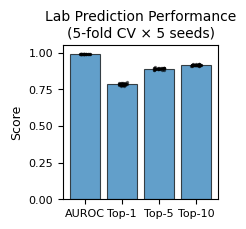

In [15]:
# Plot AUROC, Top-1, Top-5, Top-10 in a single figure
metrics = ['auroc', 'top1', 'top5', 'top10']
metric_labels = ['AUROC', 'Top-1', 'Top-5', 'Top-10']

means = [df_results[m].mean() for m in metrics]
stds = [df_results[m].std(ddof=1) for m in metrics]

x = np.arange(len(metrics))
bar_width = 0.8

plt.figure(figsize=(2, 2))

# Bar plot with error bars
bars = plt.bar(x, means, yerr=stds, width=bar_width, 
               color='C0', alpha=0.7, edgecolor='black', linewidth=0.8, capsize=3)

# Scatter individual data points
jitter = 0.15
for i, m in enumerate(metrics):
    values = df_results[m].values
    jittered_x = np.full(len(values), x[i]) + (np.random.rand(len(values)) - 0.5) * 2 * jitter
    plt.scatter(jittered_x, values, color='black', s=2, alpha=0.5, zorder=5)

plt.xticks(x, metric_labels, fontsize=9)
plt.ylabel('Score', fontsize=9)
plt.ylim(0, 1.05)
plt.title('Lab Prediction Performance\n(5-fold CV × 5 seeds)', fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.show()